Goal: Create a model that can predict the salary of the employee based on employee's years of exp

In [1]:
import pandas as pd
import numpy as np

In [3]:
data = pd.read_csv("Salary_Data.csv")

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 628.0 bytes


In [5]:
data.dropna(inplace=True)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 720.0 bytes


In [7]:
data.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


<Axes: ylabel='YearsExperience'>

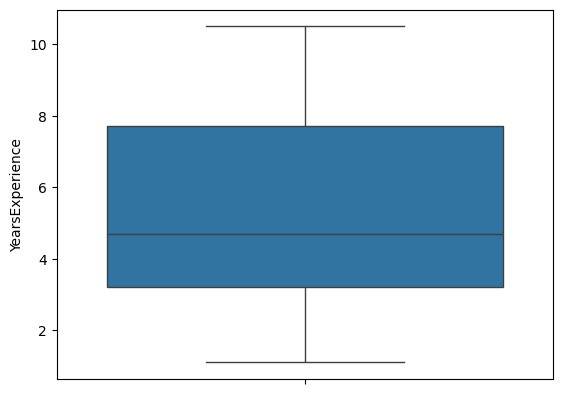

In [8]:
import seaborn as sns
sns.boxplot(data['YearsExperience'])

 Features: YearsExperience
 Label: Salary
 LabelType: Continuous ND
 Algo Category: Regression

In [9]:
#Rules for Regression in Sklearn
# 1. Data must be complete
# 2. Data must be strictly numeric
# 3. Data must be represented in the form of numpy array

In [10]:
#Step1: Seperate data as features and label

features = data.iloc[:,[0]].values
label = data.iloc[:,[1]].values

In [11]:
# Split the data into training set and testing set
# In sklearn, we have a class called train_test_split
#
# train_test_split returns 4 variables
# X_train ----- training feature set
# X_test ------ testing feature set
# y_train ----- training label set
# y_test ------ testing label set
#
#
# training data --------> (X_train,y_train) ----> Used to train the model
# testing data ---------> (X_test,y_test) ------> Used to evaluate the model

# Give 80% data for training
# Give 20% data for testing

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(features,
                                                 label,
                                                 test_size=0.2, #Declaring testing data size in percentage
                                                 random_state=1) #Control Shuffling

In [12]:
# Modelling Process
# Initialize the algo --- LinearRegression

from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [13]:
#Start the training

model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
model.predict(np.array([[2]]))

array([[44275.78747434]])

In [15]:
# Check the quality of the model
#
# SL(Significance Level) -----> 0.05
#
# CL -------------------------> 0.95 ---- The project expects the model to give atleast 95% accuracy

In [16]:
# When it comes to approving the model, always go for GENERALIZED model.
#
# Generalized model means the model not only performs best with known data, but also performs best with
# unknown data.
#
# We need a model that can understand POPULATION's PATTERN
#
# Guideline to identify if the model is a generalized model
#===============================================================================
#
# a. Calc the evaluation score of the model for both training data and testing
#    data.
#
#       trainScore --------- Score generated for training data
#       testScore ---------- Score generated for testing data
#
# b. Check the below criteria
#
#        if testScore > trainScore and testScore >= CL:
#                  Approve Model
#        else:
#                  Improve Model

In [17]:
#Training data
trainScore = model.score(X_train,y_train)

#Testing data
testScore = model.score(X_test,y_test)

SL = 0.05
CL = 1-SL

print(f"Testing Score is {testScore} and Training Score is {trainScore}")

if testScore > trainScore and testScore >= CL:
  print("Approve and Deploy the model")
else:
  print("Improve the model and recheck")
  

Testing Score is 0.7616681465472094 and Training Score is 0.9677558036981184
Improve the model and recheck


In [18]:
# Statistics says " The way how u present the data, INFLUENCE the learning power of AI Algorithm "

# Dr. Strange to check which all possibilities will give me generalized model


from sklearn.model_selection import train_test_split

SL = 0.05
CL = 1-SL

for rs in range(1,101):

  X_train,X_test,y_train,y_test = train_test_split(features,
                                                 label,
                                                 test_size=0.2, #Declaring testing data size in percentage
                                                 random_state=rs)

  model= LinearRegression()
  model.fit(X_train,y_train)

  trainScore = model.score(X_train,y_train)
  testScore = model.score(X_test,y_test)

  if testScore > trainScore and testScore >= CL:
    print(f"TestScore: {testScore} and TrainScore: {trainScore} and RS: {rs}")






TestScore: 0.9695039421049821 and TrainScore: 0.9545249190394051 and RS: 3
TestScore: 0.9631182154839476 and TrainScore: 0.9528197369259258 and RS: 8
TestScore: 0.9816423482070253 and TrainScore: 0.9494673013344644 and RS: 10
TestScore: 0.9606215790278543 and TrainScore: 0.9527636176933665 and RS: 14
TestScore: 0.9835849730044816 and TrainScore: 0.9460054870434312 and RS: 26
TestScore: 0.9636425773684423 and TrainScore: 0.9527636606684406 and RS: 27
TestScore: 0.9944092048209745 and TrainScore: 0.9400496694274887 and RS: 30
TestScore: 0.9778242092591888 and TrainScore: 0.9486350116716654 and RS: 37
TestScore: 0.972479448737762 and TrainScore: 0.9473317052697812 and RS: 38
TestScore: 0.9928344802911048 and TrainScore: 0.9492886917497556 and RS: 39
TestScore: 0.9802519469633169 and TrainScore: 0.9491742100347064 and RS: 41
TestScore: 0.9789129767378081 and TrainScore: 0.948821675263085 and RS: 46
TestScore: 0.9839919389056401 and TrainScore: 0.9486450781125915 and RS: 47
TestScore: 0.980